# **Proyecto ML - parte 1**

En primer lugar, se realizan las importaciones de las librerias necesarias para realizar el ciclo de machine learning

In [2]:
import pandas as pd
import numpy as np
import re
import unicodedata
from functools import lru_cache

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt

# Descarga las stop words de NLTK (solo se necesita la primera vez en un entorno nuevo)
nltk.download('stopwords', quiet=True)

True

Luego, se leen los datos del archivo .csv que contienen las reseñas en texto crudo a las cuales se les quiere clasificar en diferentes clases.

In [3]:
df_train = pd.read_csv("train.csv")
y_train = df_train['label']

## 1. Procesamiento de texto

Teniendo en cuenta que los textos crudos no son datos estructurados, se realiza NLP (natural language processing) para poder transformarlos en vectores y, de esta manera, permitir que los algoritmos de aprendizaje puedan usarlos.

Para esto, se utilizan representaciones dispersas (matrices dispersas) que permiten representar cada frase como un vector en un espacio vectorial semantico de dimensiones $\mathbb{R}^{|V|}$, donde |V| es el tamaño del vocabulario. Se hace uso del pipeline general definido para realizar este tipo de procesamiento:
```text
Texto crudo
    ↓  Limpieza (minúsculas, tildes, puntuación)
Texto normalizado
    ↓  Tokenización
Lista de tokens
    ↓  Stop words + Stemming
Tokens procesados
    ↓  Vectorización (BoW / TF-IDF)
Vector numérico ∈ ℝ^|V|
```

Los datos tienen tildes inconsistentes ("también" y "tambien" aparecen como si fueran palabras distintas), así que se quitan antes de procesar. Las stop words pasan por la misma función para que coincidan con el texto, y se conservan las negaciones y los intensificadores porque cambian el sentido de la opinión ("no", "nunca", "sin", "muy", "poco"...).

In [4]:
stop_words_es = set(stopwords.words('spanish'))

# Palabras relevantes que no queremos eliminar porque cambiarian la interpretación del modelo
palabras_relevantes = {"no", "nunca", "jamás", "sin", "ni", "tampoco",
"pero", "aunque","muy", "bastante", "demasiado", "más", "menos", "poco"}

stemmer = SnowballStemmer('spanish')

def quitar_tildes(texto):
    # Separa cada letra de su tilde y descarta la tilde (también convierte la ñ en n)
    descompuesto = unicodedata.normalize('NFD', texto)
    return ''.join(c for c in descompuesto if unicodedata.category(c) != 'Mn')

# Stop words sin tildes para que coincidan con el texto normalizado.
# Se restan las palabras relevantes (también sin tilde) para no perder "mas", "jamas" ni las negaciones
relevantes_sin_tilde = {quitar_tildes(p) for p in palabras_relevantes}
stop_words_sin_tilde = {quitar_tildes(p) for p in stop_words_es} - relevantes_sin_tilde

@lru_cache(maxsize=None)
def raiz(palabra):
    # Stemming con caché, porque las mismas palabras se repiten miles de veces
    return stemmer.stem(palabra)

def preprocesar_clausula(clausula):
    # A. Normalización: quitar signos de puntuación (deja solo letras y espacios)
    clausula = re.sub(r'[^\w\s]', '', clausula)

    # B. Tokenización: separar por espacios
    tokens = clausula.split()

    # C. Stopwords y Stemming: filtrar palabras vacías y extraer la raíz
    return [raiz(p) for p in tokens if p not in stop_words_sin_tilde]

Antes de aplicar el anterior proceso al texto crudo, se realiza una serie de pasos adicionales para conservar información sobre la posición de cada cláusula dentro del texto. Muchas reseñas mezclan elogios y quejas, y el sentimiento global lo define sobre todo la parte final, así que el mismo término pesa distinto según dónde aparezca ("mal" al final de la reseña no significa lo mismo que "mal" al comienzo).

Para esto, el texto se separa en cláusulas. Se corta al final de cada oración, en los punto y coma y en las comas que preceden a un conector contrastivo (sin embargo, aunque, pero, eso sí, aun así, y no). Se prefiere la cláusula a la oración porque una misma oración puede unir dos opiniones opuestas con un conector ("la batería es excelente, pero la cámara decepcionó"), y cada una debe tener su propia posición.

La última cláusula se marca con L (Last), la penúltima con P (Previous) y las demás con E (Earlier). Después, cada cláusula se preprocesa y sus tokens reciben el prefijo correspondiente. El pipeline completo para el procesamiento de los datos queda de la siguiente manera:

```text
Texto original
    ↓
Minúsculas y sin tildes
    ↓
Separación en cláusulas
    ↓
Identificación de posición
    ├── E → Cláusulas anteriores
    ├── P → Penúltima cláusula
    └── L → Última cláusula
    ↓
Preprocesamiento y tokenización
    ↓
Tokens con posición
    ↓
E_token1 E_token2 ... P_token1 P_token2 ... L_token1 L_token2 ...
```

In [5]:
# Conectores contrastivos (ya sin tildes) que abren una nueva cláusula cuando van después de una coma
CONECTORES = r'(?:sin embargo|aunque|pero|eso si|aun asi|y no)'
PATRON_CORTE = re.compile(r'(?<=[.!?])\s+|\s*;\s*|\s*,\s*(?=' + CONECTORES + r'\b)')

def separar_clausulas(texto):
    # Minúsculas, sin tildes, y corte en oraciones, punto y coma y comas antes de conectores
    texto = quitar_tildes(texto.lower().strip())
    return [c.strip() for c in PATRON_CORTE.split(texto) if c and c.strip()]

def marcar_clausulas(texto):
    # Separa en cláusulas y marca cada token según su posición
    clausulas = separar_clausulas(texto)
    n = len(clausulas)
    tokens = []
    for i, clausula in enumerate(clausulas):
        if i == n - 1:
            prefijo = "L"   # última cláusula
        elif i == n - 2:
            prefijo = "P"   # penúltima
        else:
            prefijo = "E"   # el resto
        tokens += [f"{prefijo}_{tok}" for tok in preprocesar_clausula(clausula)]
    return " ".join(tokens)

def ultima_clausula_limpia(texto):
    # Última cláusula en minúsculas, sin tildes ni puntuación y sin stemming (se usa para los caracteres)
    clausulas = separar_clausulas(texto)
    if not clausulas:
        return ""
    return re.sub(r'[^\w\s]', '', clausulas[-1])

# Versiones por lotes, que son las que recibe FunctionTransformer dentro del Pipeline.
# Se definen como funciones normales (no lambdas) para poder guardar el modelo más adelante
def marcar_clausulas_lote(textos):
    return [marcar_clausulas(t) for t in textos]

def ultima_clausula_lote(textos):
    return [ultima_clausula_limpia(t) for t in textos]

Para ver cómo funciona, se aplica el procesamiento a una reseña que tenga un conector contrastivo después de una coma.

In [6]:
mascara = df_train['text'].str.contains(r',\s*(?:pero|aunque|sin embargo)', case=False, regex=True)
ejemplo = df_train.loc[mascara, 'text'].iloc[0] if mascara.any() else df_train['text'].iloc[0]

print("Texto original:\n", ejemplo)
print("\nCláusulas:")
for c in separar_clausulas(ejemplo):
    print(" -", c)
print("\nTokens con posición:\n", marcar_clausulas(ejemplo))
print("\nÚltima cláusula (para los n-gramas de caracteres):\n", ultima_clausula_limpia(ejemplo))

Texto original:
 Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los días en la oficina y ya le agarré la práctica, aunque mis compañeros se ríen de lo desordenado que tengo el escritorio. El micrófono me pareció decente para ser honesto.

Cláusulas:
 - compre este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llego en tres dias a casa.
 - la verdad, el cargador me parecio terrible para mi gusto.
 - lo uso casi todos los dias en la oficina y ya le agarre la practica
 - aunque mis companeros se rien de lo desordenado que tengo el escritorio.
 - el microfono me parecio decente para ser honesto.

Tokens con posición:
 E_compr E_kit E_mes E_pas E_necesit E_videollam E_trabaj E_lleg E_tres E_dias E_cas E_verd E_cargador E_pareci E_terribl E_gust E_uso E_casi E_dias E_oficin E_agarr E_practic P_aunqu P_companer P_rien P

## 2. Representación del texto

Luego de aplicar todas las transformaciones necesarias al texto crudo mediante NLP, se procede a representar el texto resultante en diferentes vectores, donde cada fila representa un texto y cada columna representa una palabra o combinación de palabras (n-grama) del vocabulario. Para esto, se utiliza TF-IDF, que asigna un peso a cada término según su frecuencia en el texto y su importancia dentro de cada reseña. Ademas, se utiliza un ajuste logarítmico de la frecuencia (sublinear_tf) para reducir el impacto de palabras que aparecen muchas veces.

La representación final combina dos bloques que se concatenan con `FeatureUnion`.

- **Bloque de palabras.** TF-IDF de unigramas y bigramas sobre los tokens con posición. Se usa `lowercase=False` para que los prefijos queden como `E_`, `P_` y `L_` (por defecto el vectorizador los pasaría a minúscula).
- **Bloque de caracteres.** TF-IDF de n-gramas de caracteres (`char_wb`, de 2 a 5) calculado solo sobre la última cláusula, que es la que más pesa en el sentimiento global. Los datos tienen errores de ortografía ("encmia", "peero", "taalle") que el stemming no corrige, y los n-gramas de caracteres siguen compartiendo fragmentos con la palabra bien escrita.

Todo se arma dentro de un `Pipeline`, junto con las funciones de preprocesamiento (`FunctionTransformer`) y el clasificador. De esta forma, durante la validación cruzada el vocabulario y los pesos IDF se ajustan únicamente con los datos de entrenamiento de cada fold, y el modelo final es un solo objeto que recibe texto crudo.

In [7]:
# Bloque de palabras: marcas de posición por cláusula + TF-IDF de unigramas y bigramas
bloque_palabras = Pipeline([
    ('marcar', FunctionTransformer(marcar_clausulas_lote)),
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,      # suaviza palabras repetidas: usa 1 + log(tf)
        min_df=2,
        token_pattern=r'\S+',   # cada token separado por espacio cuenta entero, con su prefijo
        lowercase=False         # conserva los prefijos E_, P_, L_ en mayúscula
    ))
])

# Bloque de caracteres: n-gramas de caracteres de la última cláusula, robustos a errores de ortografía
bloque_caracteres = Pipeline([
    ('ultima', FunctionTransformer(ultima_clausula_lote)),
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',     # n-gramas dentro de los límites de cada palabra
        ngram_range=(2, 5),
        min_df=3,
        sublinear_tf=True
    ))
])

# Los dos bloques se concatenan en una sola matriz dispersa
representacion = FeatureUnion([
    ('palabras', bloque_palabras),
    ('caracteres', bloque_caracteres)
])

## 3. Modelo 1: Regresión Logística

La Regresión Logística es un clasificador lineal que, para cada clase (negativo, neutral, positivo), aprende un peso por cada término del vocabulario. Para predecir, suma los pesos de los términos presentes en la reseña y convierte el resultado en probabilidades con la función softmax. La clase con mayor probabilidad es la predicción.

Se eligió porque:
- Funciona muy bien con representaciones dispersas y de alta dimensión como TF-IDF.
- Es interpretable: los pesos muestran qué términos empujan hacia cada clase (por ejemplo, `L_excelent` hacia positivo).
- Entrega probabilidades, útiles para analizar la confianza del modelo o para combinarlo con otros modelos.

Para estimar su desempeño en datos no vistos se usa validación cruzada estratificada a traves de 5 particiones: los datos se dividen en 5 partes con la misma proporción de clases; se entrena con 4 y se evalúa con la restante, rotando 5 veces. El accuracy final es el promedio.

In [8]:
# Validación cruzada estratificada: 5 particiones que mantienen la proporción de clases.
# shuffle=True mezcla los datos antes de dividir y random_state=42 hace que la división sea replicable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline completo: texto crudo -> cláusulas con posición -> TF-IDF (palabras + caracteres) -> Regresión Logística
modelo = Pipeline([
    ('rep', representacion),
    ('clf', LogisticRegression(
        C=10,            # Inverso de la regularización: C alto = menos regularización, el modelo se ajusta más a los datos
        max_iter=2000,   # Iteraciones máximas del optimizador; con tantas features necesita más de las 100 por defecto para converger
        random_state=42  # Semilla para que los resultados sean replicables
    ))
])

# Entrena y evalúa el modelo 5 veces, una por cada fold, y devuelve el accuracy de cada una.
# Como el vectorizador está dentro del pipeline, su vocabulario se ajusta solo con el fold de entrenamiento
scores = cross_val_score(modelo, df_train['text'], y_train, cv=cv, scoring='accuracy')

print("Accuracy por fold:", scores.round(4))
print(f"Accuracy promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")

Accuracy por fold: [0.8954 0.8892 0.8942 0.8925 0.8862]
Accuracy promedio: 0.8915 (+/- 0.0034)


### Análisis de resultados por clase

El accuracy promedio no muestra en qué clases se equivoca el modelo. Para verlo se usa `cross_val_predict`, que devuelve la predicción de cada reseña hecha por el modelo del fold en el que esa reseña quedó como validación. Así se obtienen predicciones de las 12.000 reseñas sin que el modelo haya visto ninguna durante su entrenamiento.

Con esas predicciones se construyen:
- **Reporte de clasificación:** precisión, recall y F1 por clase.
- **Matriz de confusión:** cuántas reseñas de cada clase real fueron asignadas a cada clase predicha.

              precision    recall  f1-score   support

    negativo     0.8568    0.8497    0.8533      4212
     neutral     0.9742    0.9933    0.9837      3576
    positivo     0.8540    0.8469    0.8504      4212

    accuracy                         0.8915     12000
   macro avg     0.8950    0.8966    0.8958     12000
weighted avg     0.8908    0.8915    0.8911     12000



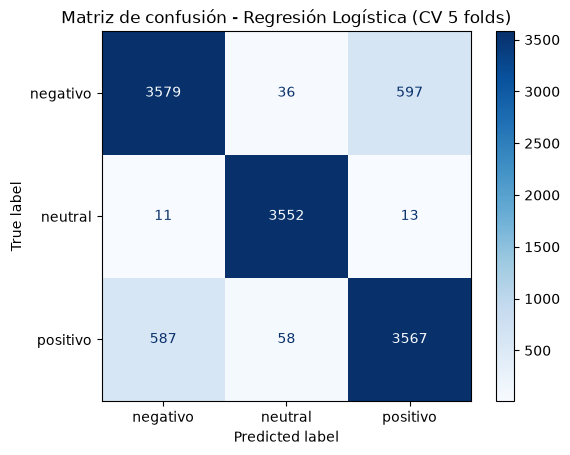

Errores totales: 1302 | confusiones positivo<->negativo: 1184


In [9]:
# Predicción de cada reseña con el modelo del fold donde quedó como validación
y_pred_cv = cross_val_predict(modelo, df_train['text'], y_train, cv=cv)

# Precisión, recall y F1 por clase
print(classification_report(y_train, y_pred_cv, digits=4))

# Matriz de confusión: filas = clase real, columnas = clase predicha
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_cv, cmap='Blues')
plt.title("Matriz de confusión - Regresión Logística (CV 5 folds)")
plt.show()

# Cuántos errores son confusiones entre positivo y negativo
errores = (y_train != y_pred_cv)
opinion = y_train.isin(["positivo", "negativo"]) & pd.Series(y_pred_cv, index=y_train.index).isin(["positivo", "negativo"])
print(f"Errores totales: {errores.sum()} | confusiones positivo<->negativo: {(errores & opinion).sum()}")

### Conclusiones del Modelo 1

La Regresión Logística con TF-IDF de palabras y caracteres y marcas de posición por cláusula alcanza un accuracy promedio de 89,15 % en validación cruzada, con una desviación de apenas ±0,34 % entre folds. El modelo es estable y no depende de una partición en particular.

El análisis por clase muestra un comportamiento muy desigual:

| Clase | Precisión | Recall | F1 |
| --- | --- | --- | --- |
| Neutral | 97,42 % | 99,33 % | 98,37 % |
| Negativo | 85,68 % | 84,97 % | 85,33 % |
| Positivo | 85,40 % | 84,69 % | 85,04 % |

- **Neutral se clasifica casi perfecto.** Estas reseñas solo describen aspectos logísticos (envío, color, tamaño, contenido de la caja) y no contienen términos de opinión, así que el modelo las separa con facilidad.
- **El problema está entre positivo y negativo.** De los 1.302 errores, 1.184 (91 %) son reseñas positivas clasificadas como negativas (587) o negativas clasificadas como positivas (597). Son las reseñas que mezclan elogios y quejas, donde el sentimiento global depende del conector contrastivo ("aun así", "eso sí", "sin embargo") y de la parte que viene después.

## 4. Generacion de las predicciones y archivo final

Finalmente, se comprueba la calidad del modelo al enfrentarse a datos totalmente nuevos. Como el preprocesamiento, los vectorizadores y el clasificador están dentro de un solo `Pipeline`, basta con reentrenarlo con todo train y llamar a `predict` sobre el texto crudo de eval.

In [10]:
# 4. Generación de Predicciones para Kaggle

# Re-entrenar el pipeline completo con el 100% de los datos de train
modelo.fit(df_train['text'], y_train)

# Cargar los archivos de evaluación y formato
df_eval = pd.read_csv("eval.csv")
df_sub = pd.read_csv("sample_submission.csv")

# Generar predicciones (el pipeline aplica las cláusulas, los vectorizadores y el clasificador)
df_pred = pd.DataFrame({"id": df_eval["id"], "answer": modelo.predict(df_eval["text"])})

# Ordenar según sample_submission para garantizar el mismo orden de ids
df_sub = df_sub[["id"]].merge(df_pred, on="id", how="left")

# Verificación de formato
assert df_sub.columns.tolist() == ["id", "answer"], "Las columnas no coinciden con el formato esperado"
assert len(df_sub) == len(df_eval), "Distinto número de filas que eval.csv"
assert df_sub["id"].is_unique, "Hay ids repetidos"
assert df_sub["answer"].notna().all(), "Hay ids sin predicción"
assert set(df_sub["answer"]) <= set(y_train.unique()), "Hay etiquetas fuera de las tres clases"
print("Formato verificado contra sample_submission.")

# Distribución de clases predichas
print("\nDistribución de predicciones (proporción):")
print(df_sub["answer"].value_counts(normalize=True).round(4))

# Exportar
df_sub.to_csv("submission_logreg_v2_grupo18.csv", index=False)

Formato verificado contra sample_submission.

Distribución de predicciones (proporción):
answer
negativo    0.3577
positivo    0.3563
neutral     0.2860
Name: proportion, dtype: float64
